In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

In [4]:
df = pd.read_csv("../data/raw/16P.csv", encoding="latin1")

In [5]:
df.drop("Response Id" , axis=1 , inplace=True)

In [6]:
personalities = pd.DataFrame({
    "Is_Extrovert": df["Personality"].map(lambda x: 1 if x[0] == 'E' else 0),
    "Is_Sensor": df["Personality"].map(lambda x: 1 if x[1] == 'S' else 0),
    "Is_Thinker": df["Personality"].map(lambda x: 1 if x[2] == 'T' else 0),
    "Is_Judger": df["Personality"].map(lambda x: 1 if x[3] == 'J' else 0)
})

In [7]:
personalities.head()

,Is_Extrovert,Is_Sensor,Is_Thinker,Is_Judger
0,1,0,0,0
1,0,1,0,0
2,0,0,0,1
3,0,1,1,0
4,1,0,0,1


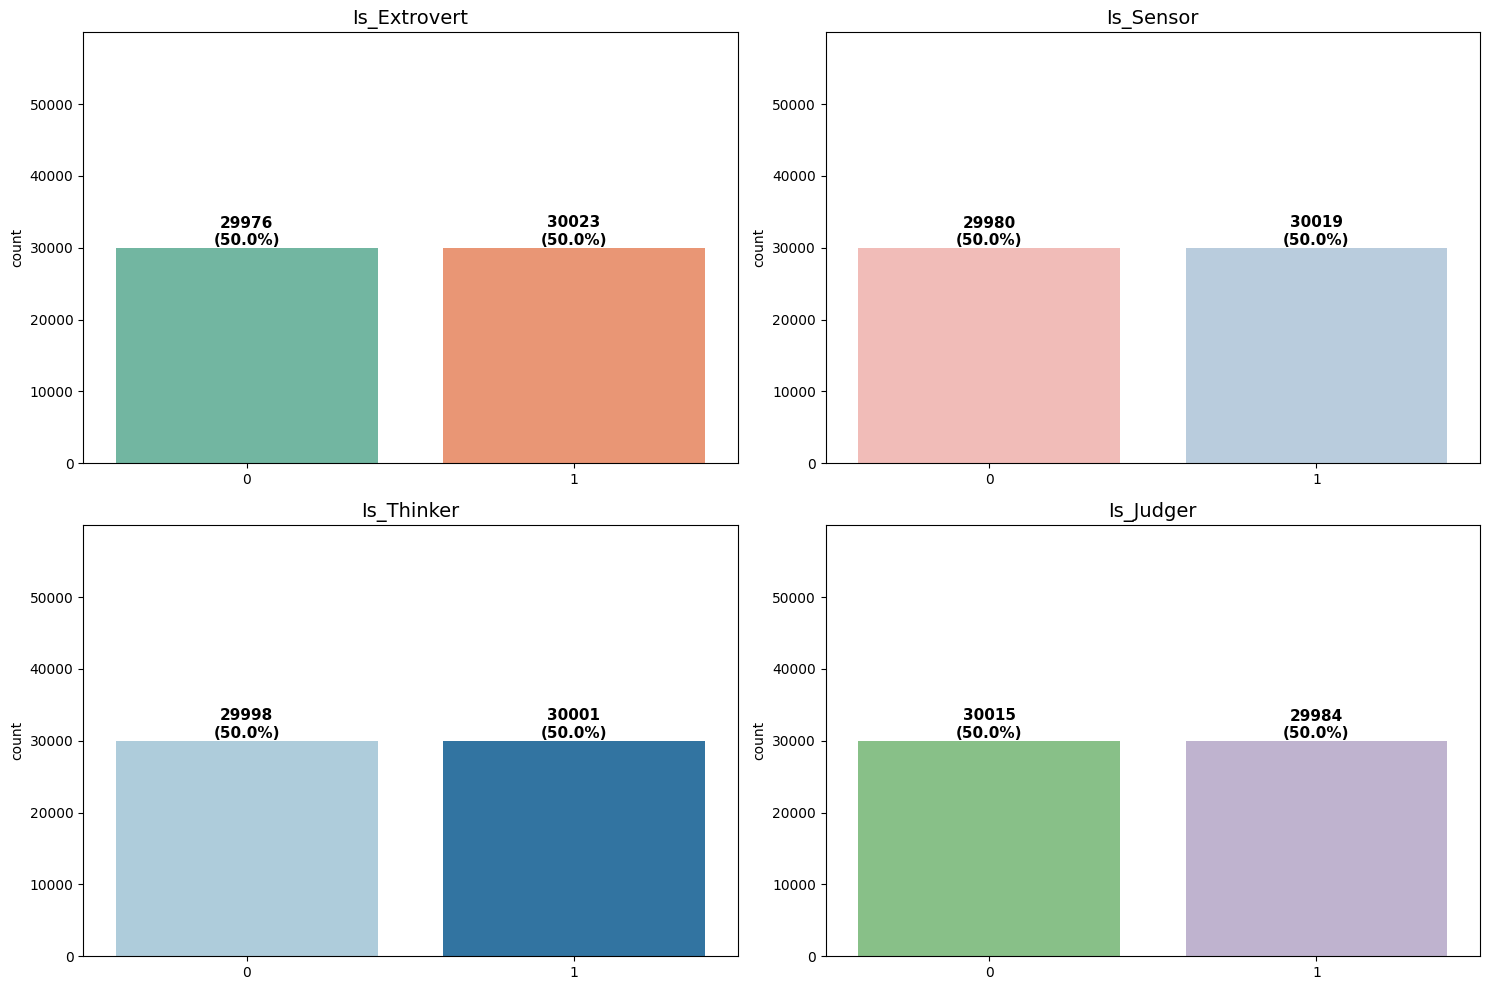

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

traits = ["Is_Extrovert", "Is_Sensor", "Is_Thinker", "Is_Judger"]
colors = ["Set2", "Pastel1", "Paired", "Accent"]

for i, trait in enumerate(traits):
    row = i // 2
    col = i % 2
    
    ax = axes[row, col]
    sns.countplot(x=trait, data=personalities, ax=ax, palette=colors[i], hue=trait, legend=False)
    
    total = len(personalities)
    for p in ax.patches:
        percentage = f"{100 * p.get_height() / total:.1f}%"
        ax.annotate(f"{int(p.get_height())}\n({percentage})", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="black")

    ax.set_title(f"{trait}", fontsize=14)
    ax.set_ylim(0, total)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

<Axes: >

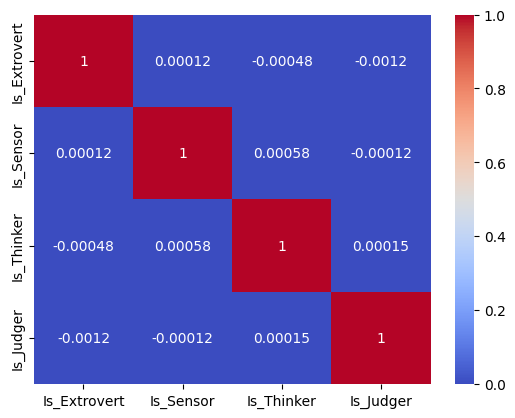

In [9]:
sns.heatmap(personalities.corr(), annot=True, cmap="coolwarm")

In [10]:
df_temp = df["Personality"]

In [11]:
df["Personality"] = df["Personality"].astype("category").cat.codes

In [12]:
df_ref = pd.DataFrame({
    "Personality": df_temp,
    "Personality_Code": df["Personality"]
})

In [14]:
df_ref.value_counts().sort_values(ascending=False)

Personality  Personality_Code
ESFP         5                   3769
INFJ         8                   3761
ENFP         1                   3760
ENTP         3                   3760
ESTJ         6                   3759
ISTJ         14                  3756
ISTP         15                  3755
ESTP         7                   3749
ISFP         13                  3746
ESFJ         4                   3746
ENFJ         0                   3743
INTJ         10                  3743
INTP         11                  3742
ISFJ         12                  3739
ENTJ         2                   3737
INFP         9                   3734
Name: count, dtype: int64

C:\Users\rawan osama\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


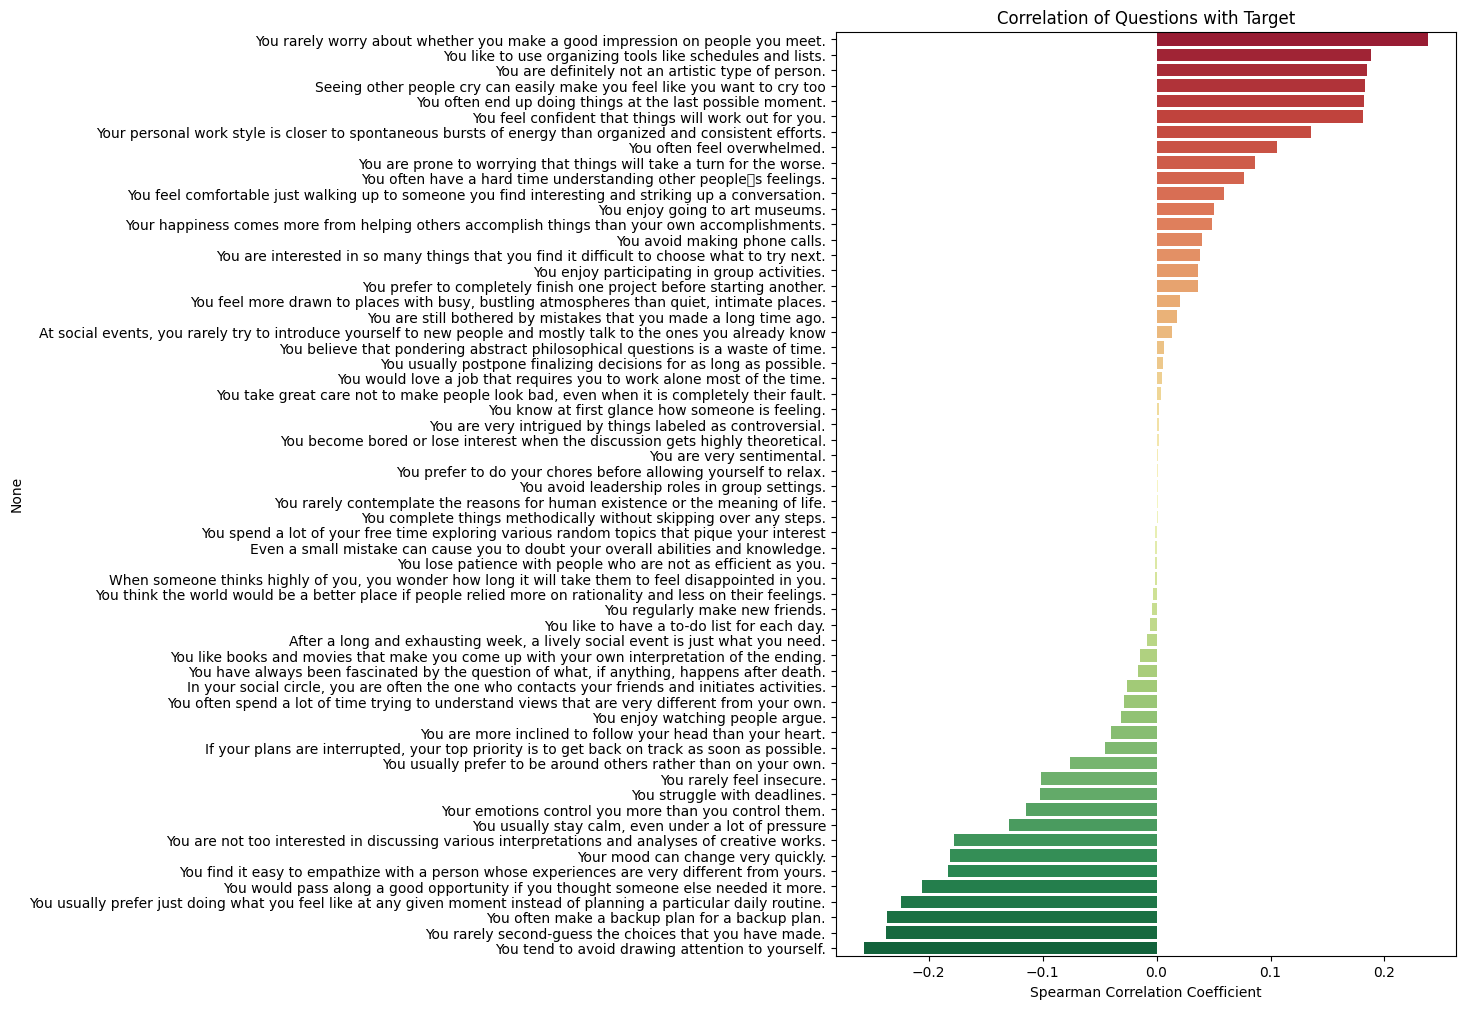

In [15]:
target_corr = df.corr(method="spearman")["Personality"].drop("Personality").sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="RdYlGn", hue=target_corr.index, legend=False)
plt.title("Correlation of Questions with Target")
plt.xlabel("Spearman Correlation Coefficient")
plt.show()

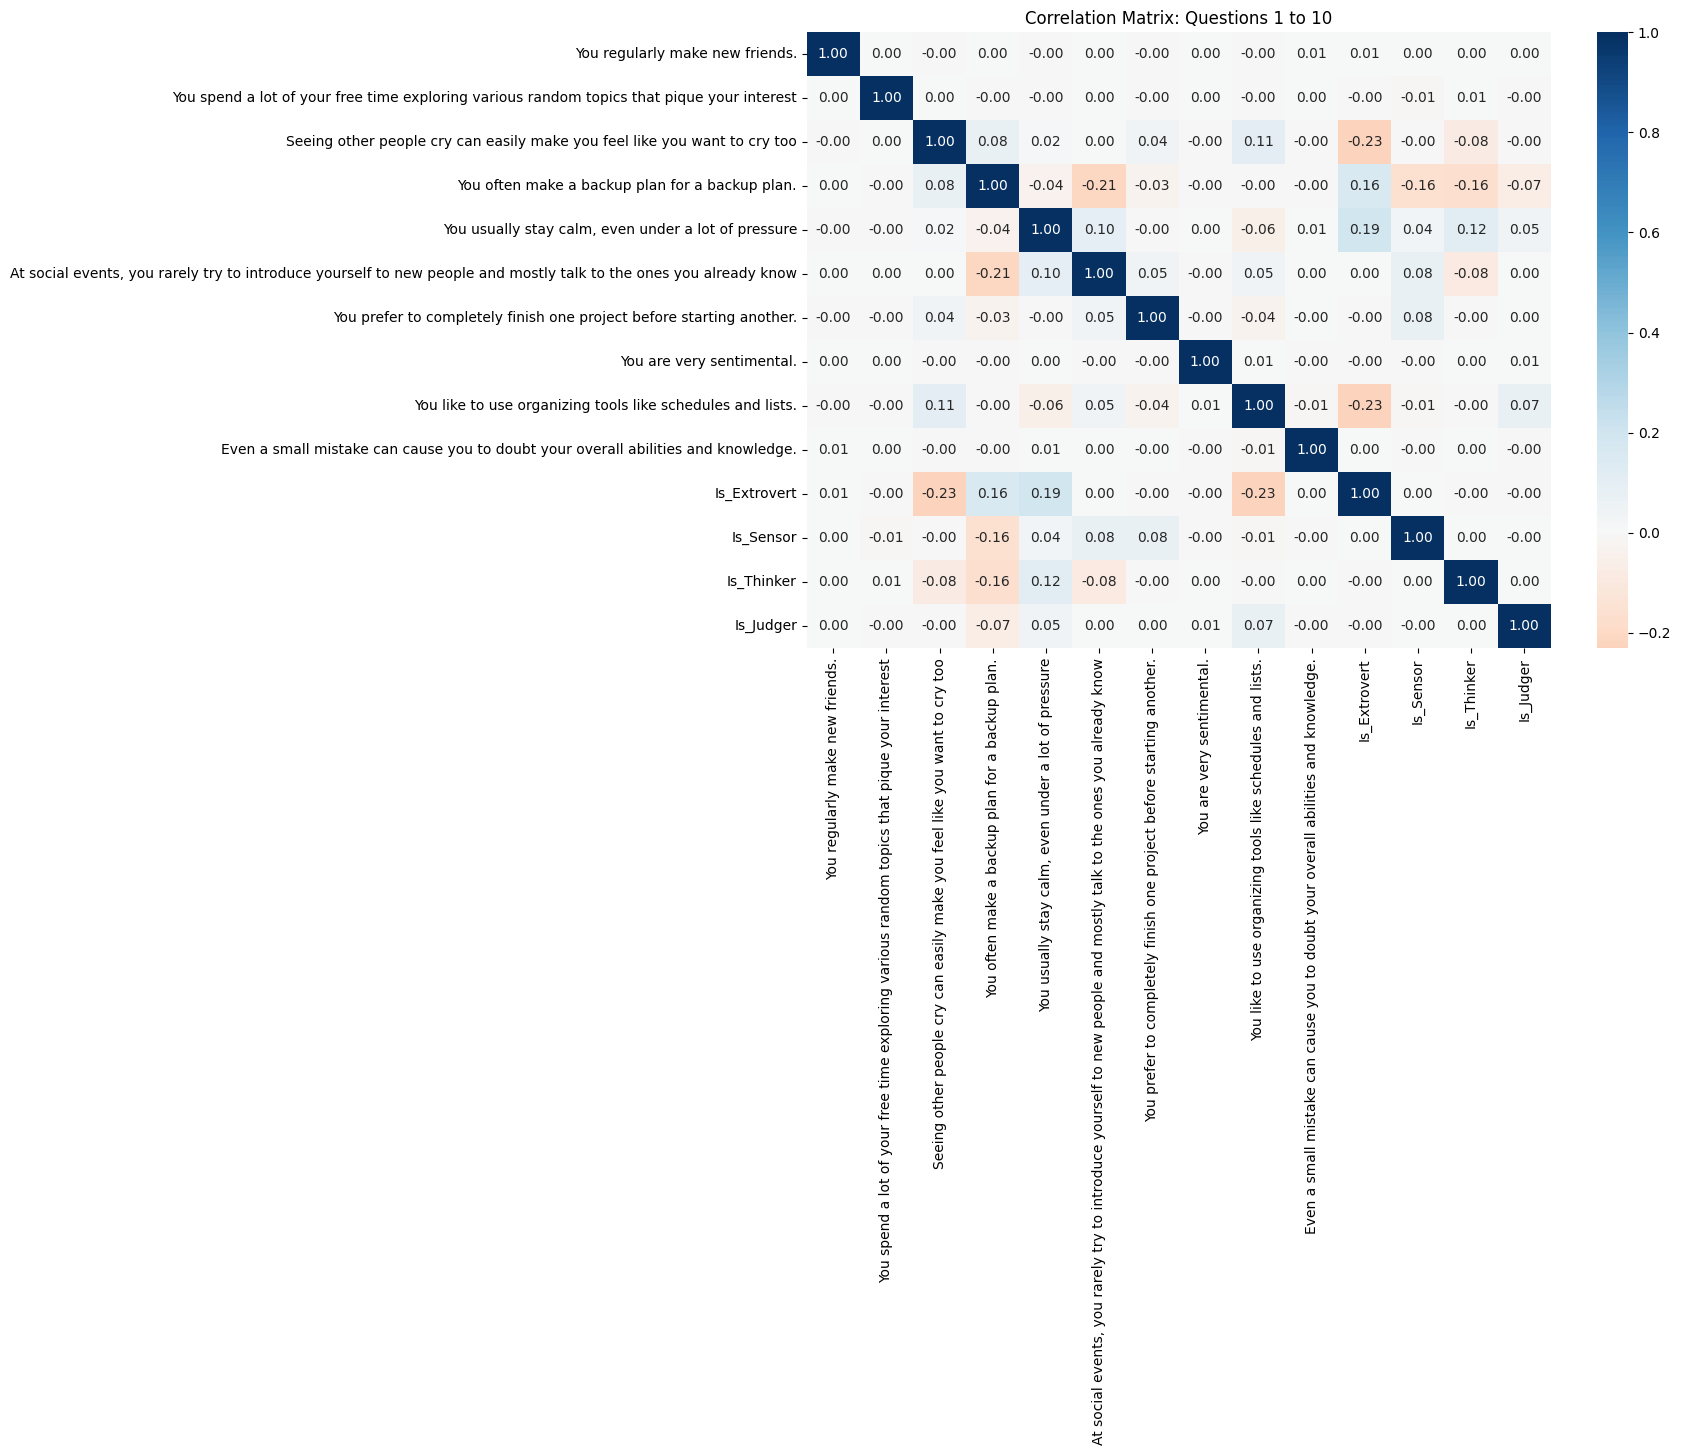

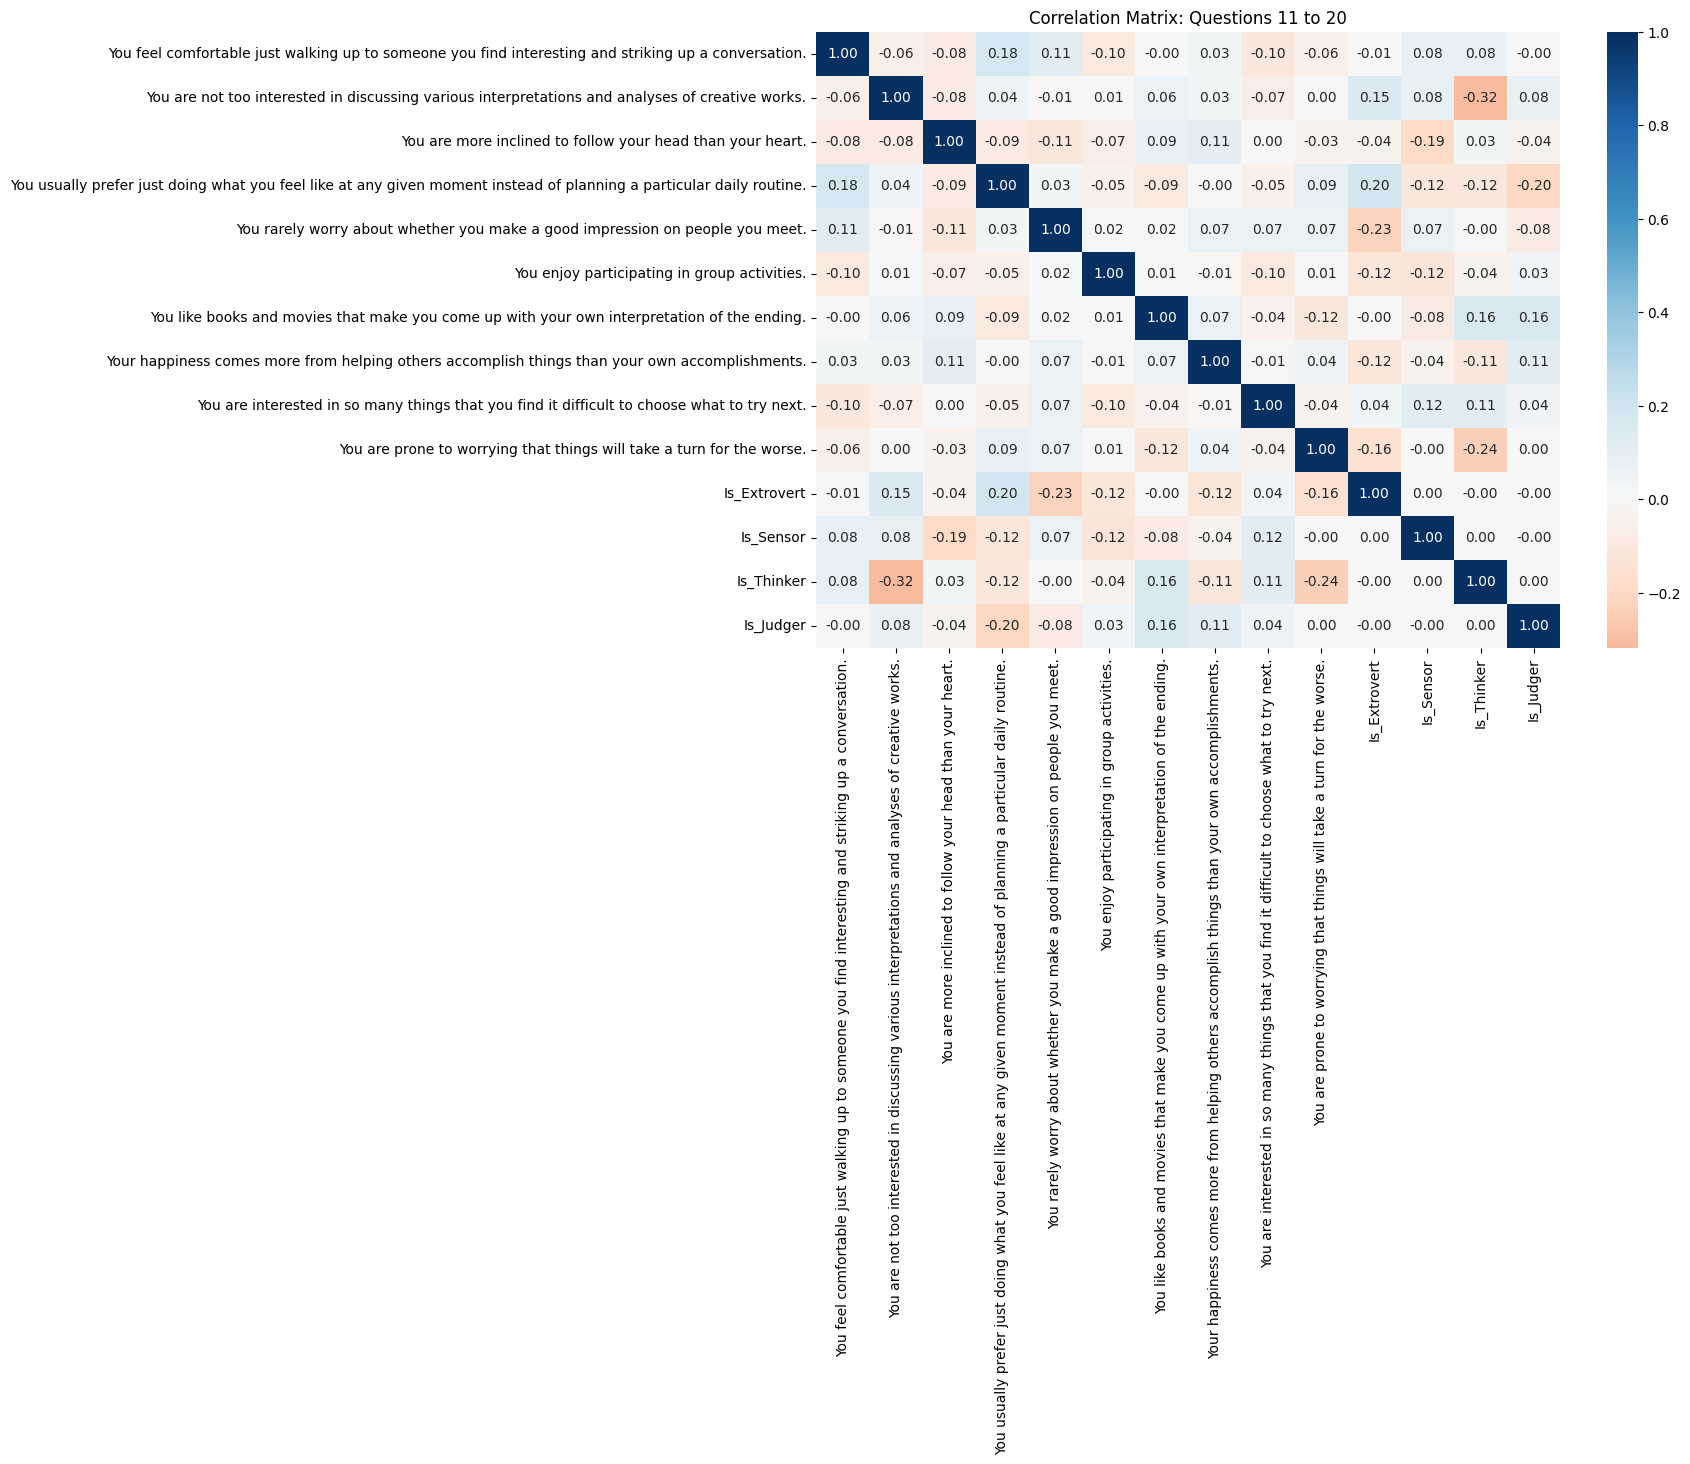

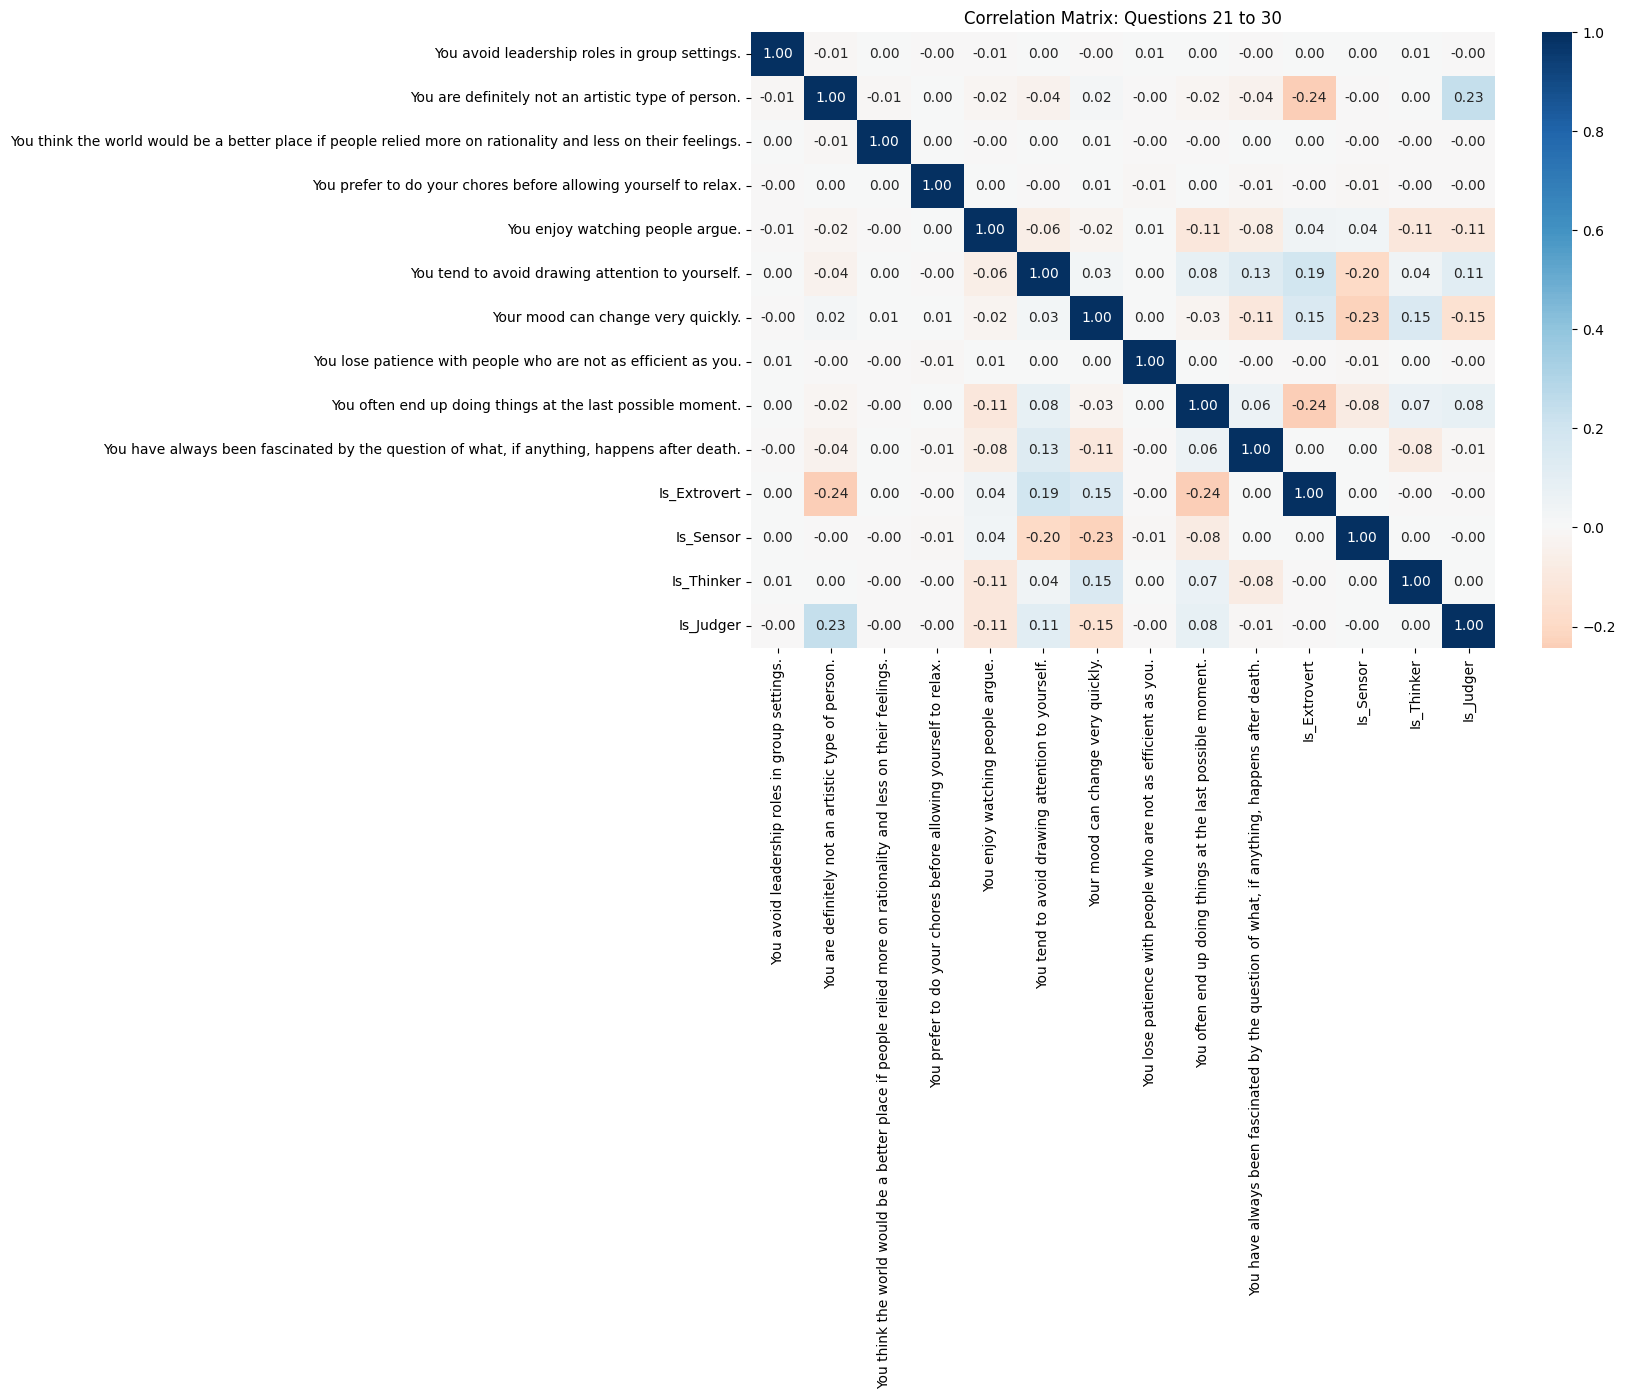

c:\Users\rawan osama\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rawan osama\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


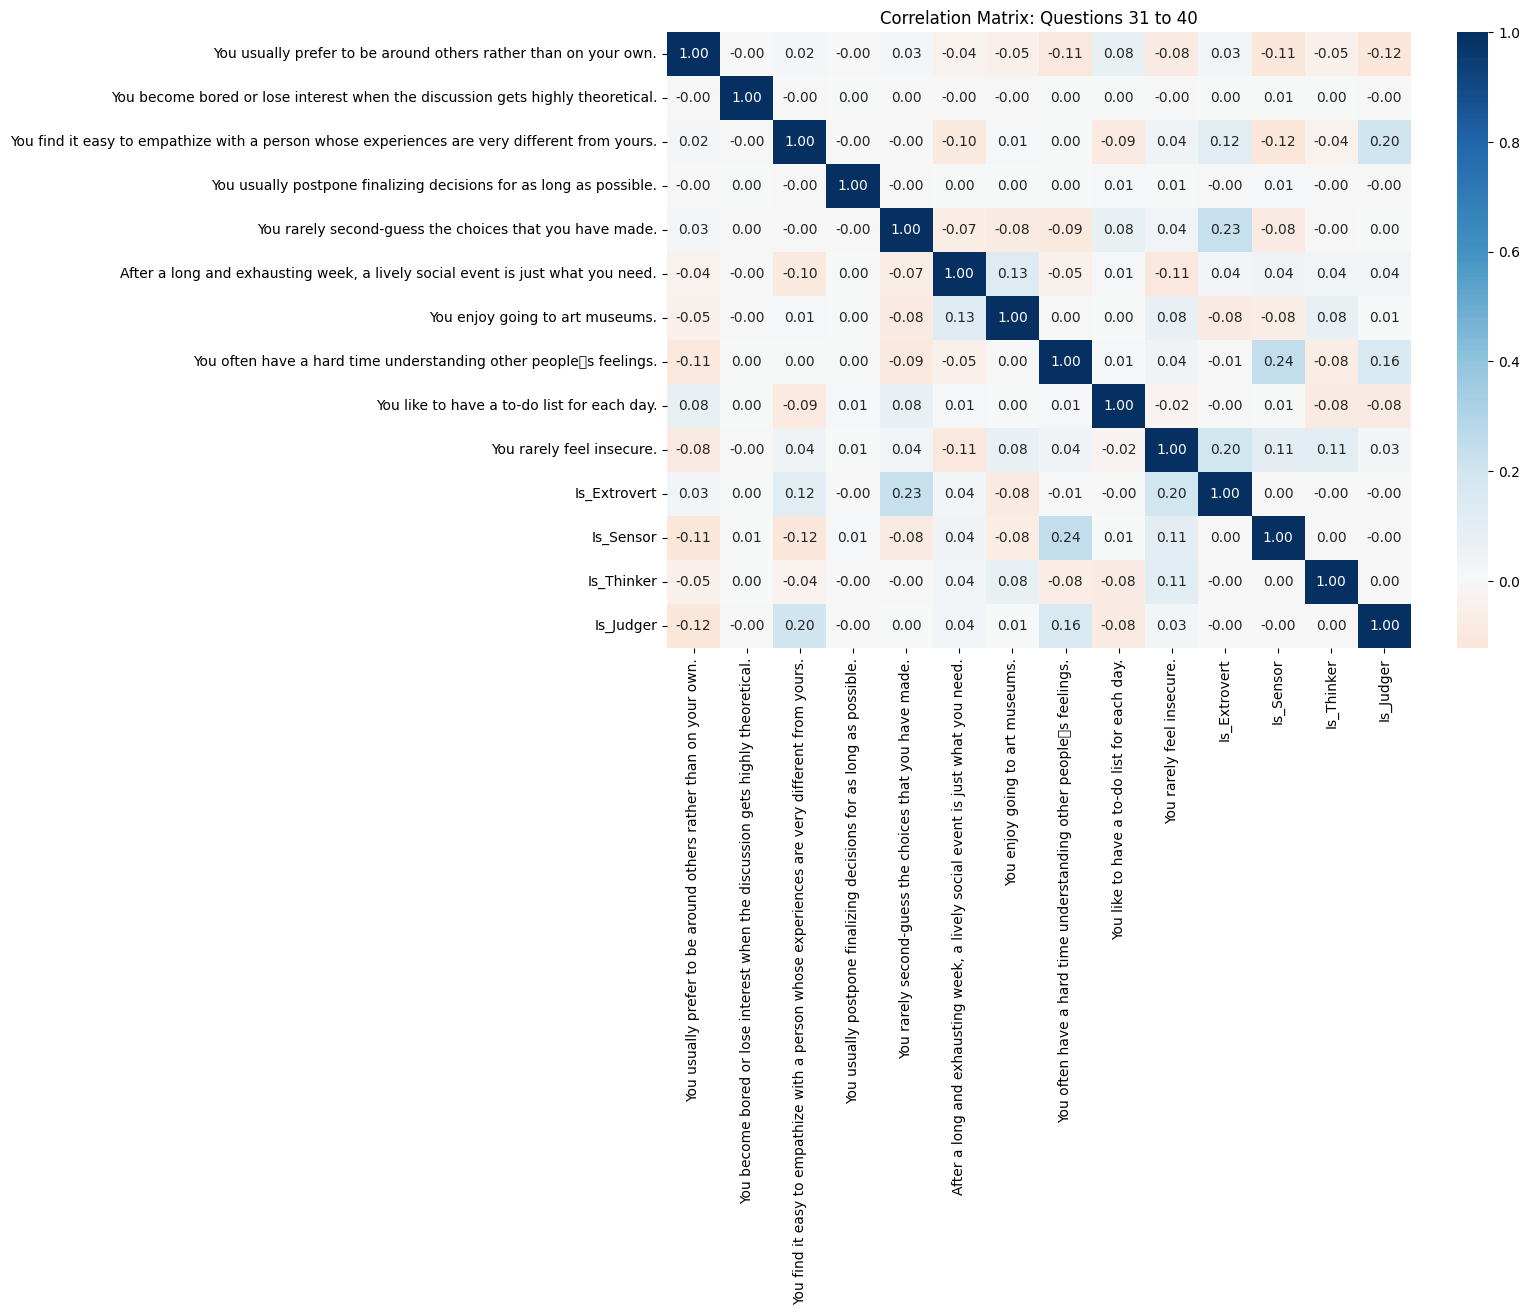

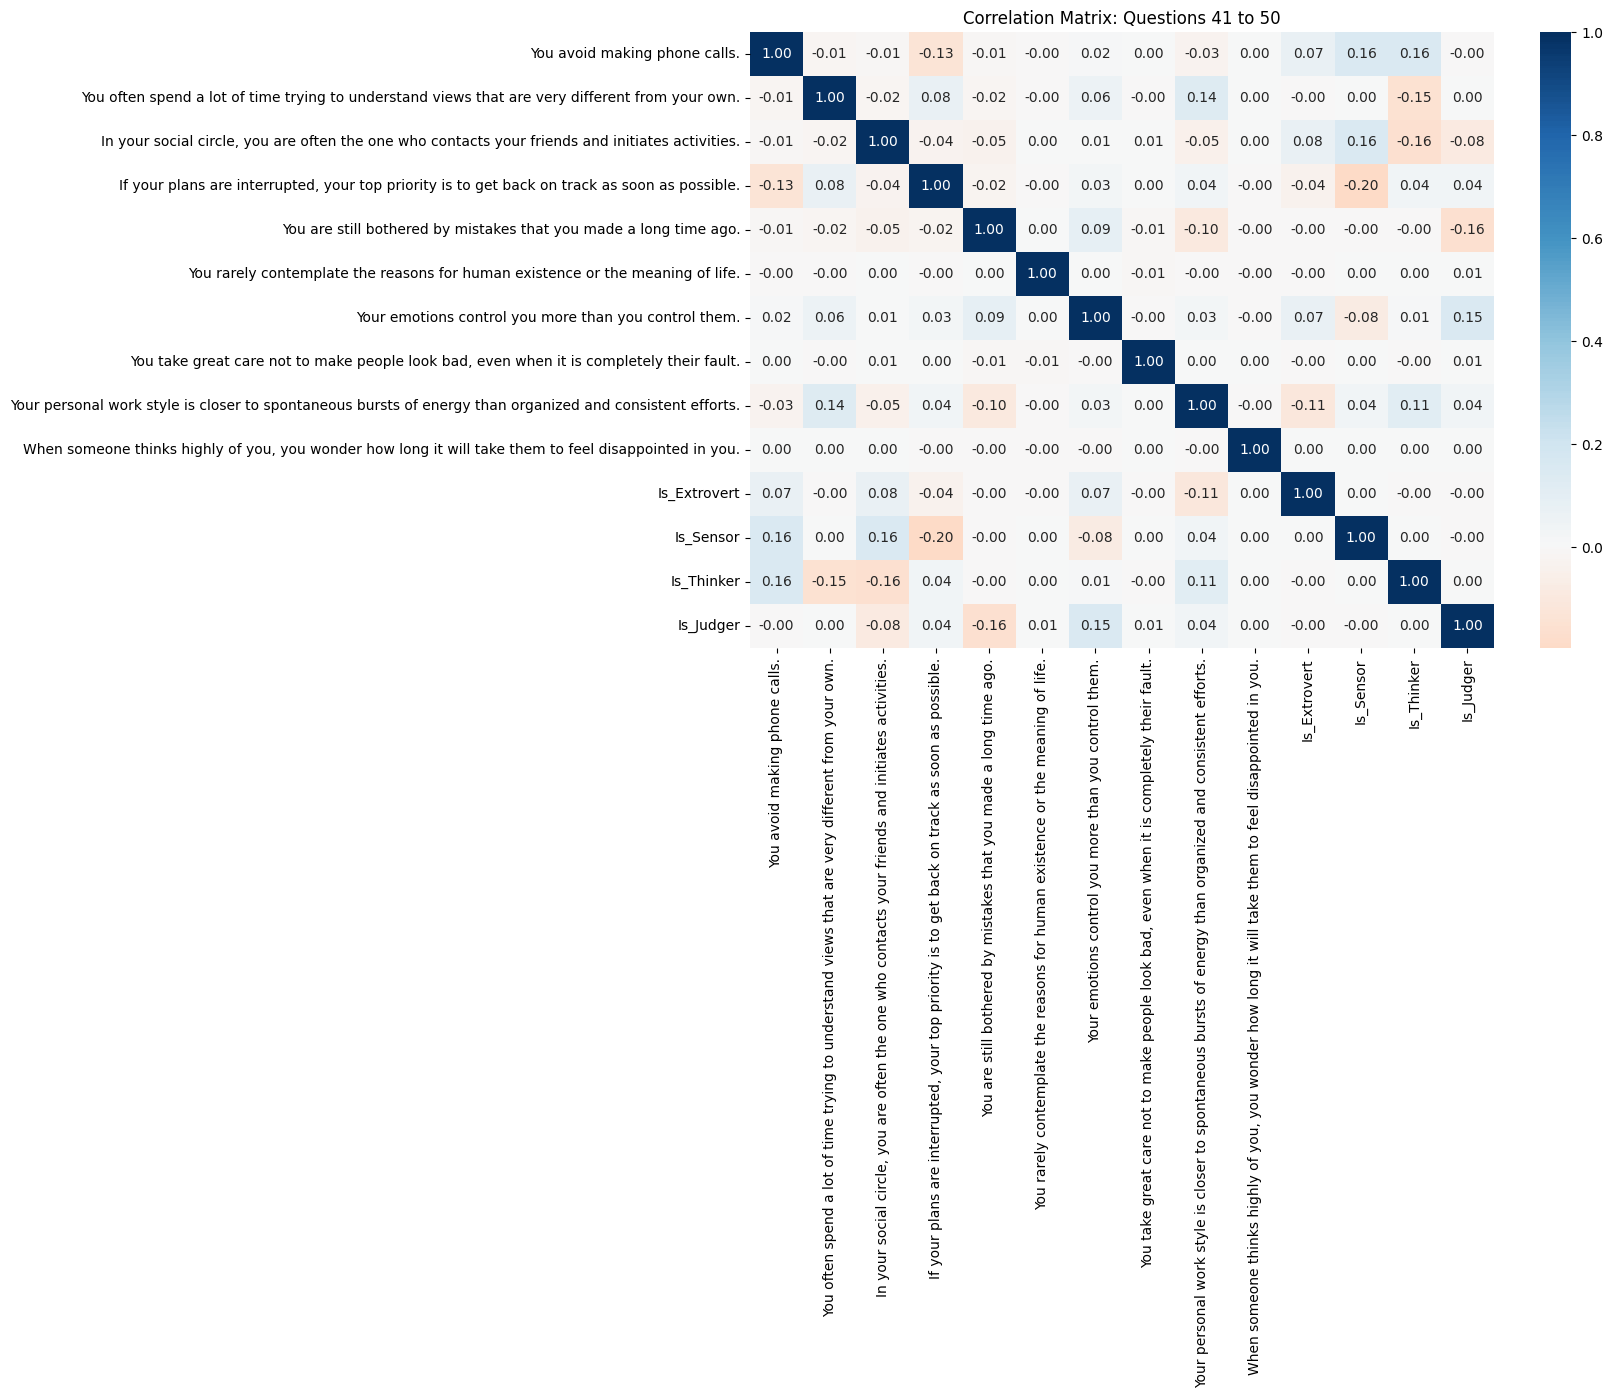

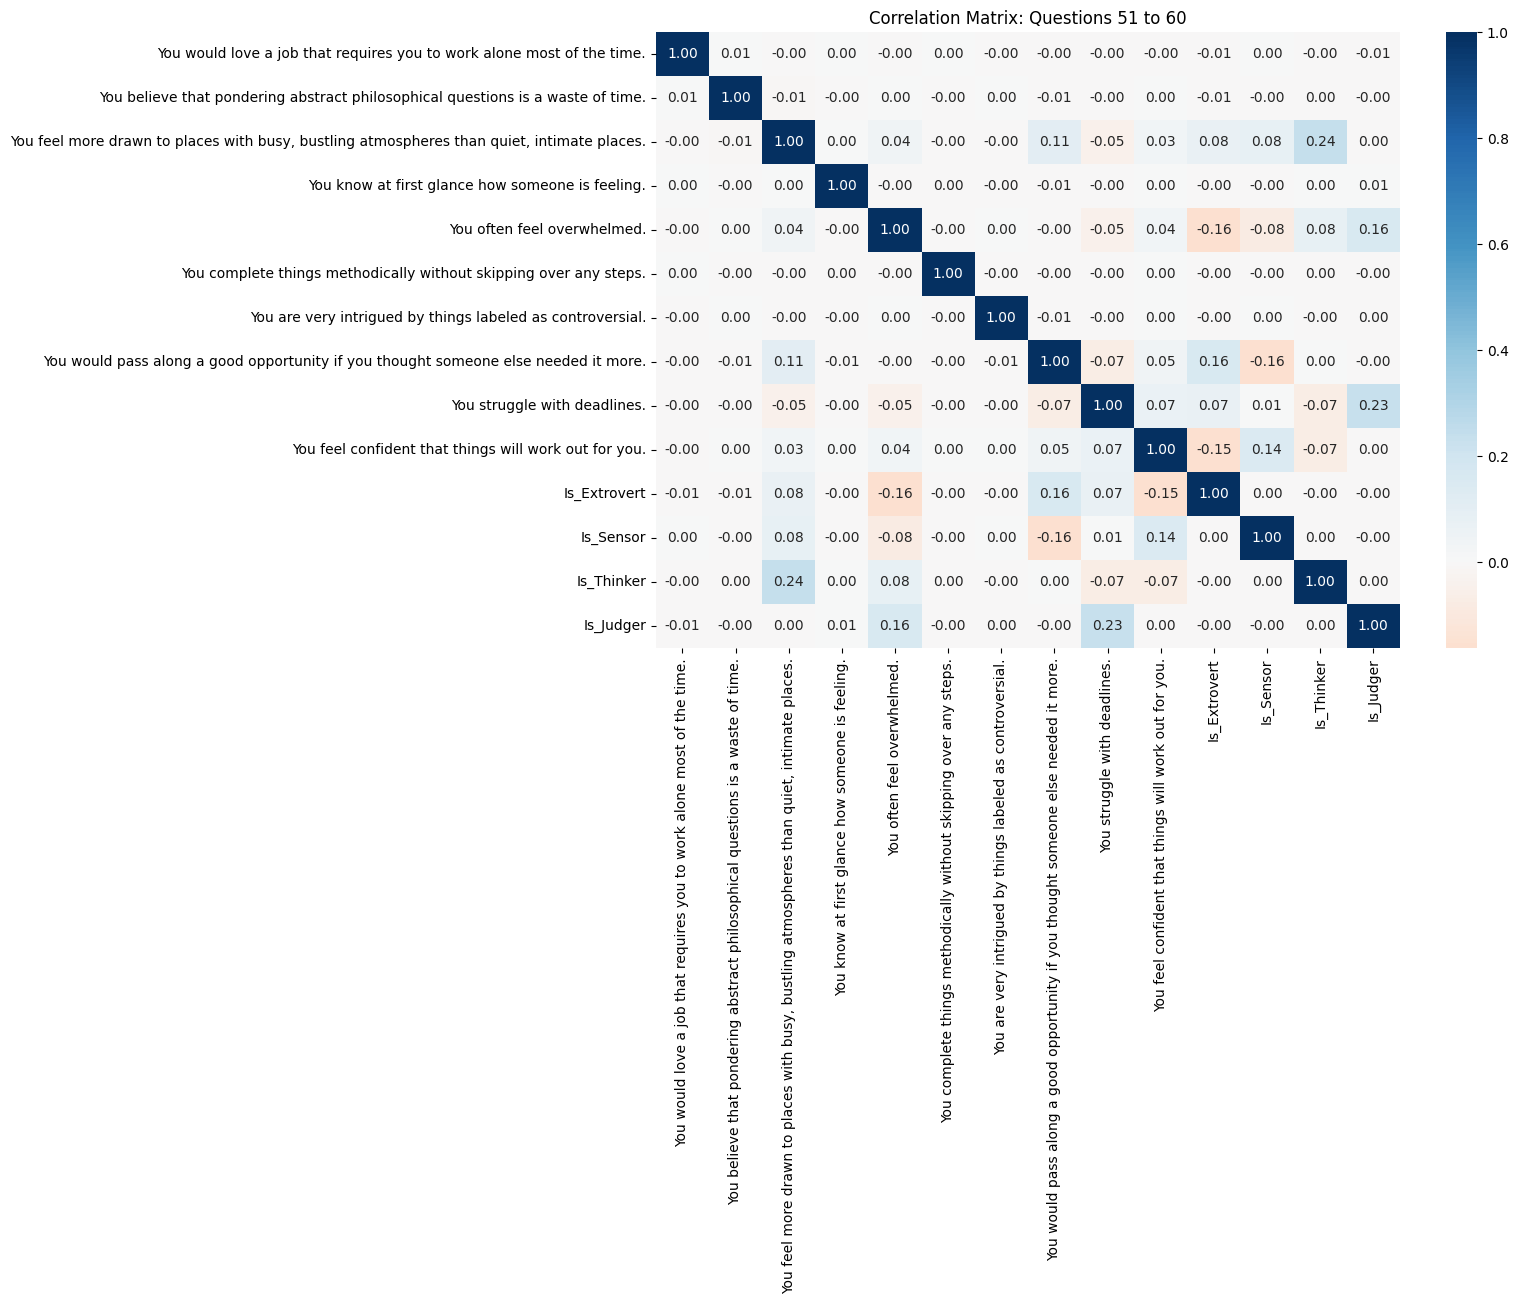

In [16]:
questions_df = df.drop("Personality", axis=1)
combined_df = pd.concat([questions_df, personalities], axis=1)

chunk_size = 10
question_cols = questions_df.columns
personality_cols = ["Is_Extrovert", "Is_Sensor", "Is_Thinker", "Is_Judger"]

for i in range(0, len(question_cols), chunk_size):
    current_questions = question_cols[i : i + chunk_size]
    subset_df = combined_df[list(current_questions) + personality_cols]

    corr_matrix = subset_df.corr(method="spearman")
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="RdBu", center=0, fmt=".2f")
    plt.title(f"Correlation Matrix: Questions {i+1} to {i+len(current_questions)}")
    plt.show()

In [17]:
combined_df

,You regularly make new friends.,You spend a lot of your free time exploring various random topics that pique your interest,Seeing other people cry can easily make you feel like you want to cry too,You often make a backup plan for a backup plan.,"You usually stay calm, even under a lot of pressure","At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",You prefer to completely finish one project before starting another.,You are very sentimental.,You like to use organizing tools like schedules and lists.,Even a small mistake can cause you to doubt your overall abilities and knowledge.,...,You often feel overwhelmed.,You complete things methodically without skipping over any steps.,You are very intrigued by things labeled as controversial.,You would pass along a good opportunity if you thought someone else needed it more.,You struggle with deadlines.,You feel confident that things will work out for you.,Is_Extrovert,Is_Sensor,Is_Thinker,Is_Judger
0,0,0,0,0,0,1,1,0,0,0,...,-1,0,0,0,0,0,1,0,0,0
1,0,0,-2,-3,-1,2,-2,0,3,0,...,2,0,-1,-1,-1,3,0,1,0,0
2,0,0,2,0,-1,2,0,0,1,0,...,2,-1,0,1,2,1,0,0,0,1
3,0,-1,3,-1,0,0,-2,0,-2,0,...,-1,0,1,0,-2,-1,0,1,1,0
4,0,0,-1,0,2,-1,-2,0,1,0,...,2,0,1,-1,2,-1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59994,0,-1,0,-3,-2,2,1,0,1,0,...,1,0,0,2,3,3,0,0,0,1
59995,0,0,-2,1,3,0,-3,0,2,0,...,0,0,0,2,0,-2,1,1,1,0
59996,0,0,1,0,-2,-2,0,0,-1,0,...,-3,0,1,-1,0,-1,0,1,1,0
59997,0,0,1,-1,-2,-1,2,0,1,0,...,2,0,0,0,1,0,0,1,1,1


In [18]:
X = combined_df.drop(personality_cols, axis=1)

mi_results = pd.DataFrame(index=X.columns)

for trait in personality_cols:
    print(f"Calculating Mutual Info for: {trait}...")
    
    scores = mutual_info_classif(X, personalities[trait], discrete_features=False, random_state=42)

    mi_results[trait] = scores

mi_results["Average_Score"] = mi_results.mean(axis=1)
top_questions = mi_results.sort_values(by="Average_Score", ascending=False)

print("\nTop 20 Questions by Mutual Information:")
print(top_questions.head(20))

Calculating Mutual Info for: Is_Extrovert...
Calculating Mutual Info for: Is_Sensor...
Calculating Mutual Info for: Is_Thinker...
Calculating Mutual Info for: Is_Judger...

Top 20 Questions by Mutual Information:
                                                    Is_Extrovert  Is_Sensor  \
You are not too interested in discussing variou...      0.014349   0.004064   
You are definitely not an artistic type of person.      0.031630   0.002650   
Your mood can change very quickly.                      0.009654   0.027302   
You usually prefer just doing what you feel lik...      0.021597   0.006856   
You tend to avoid drawing attention to yourself.        0.020251   0.023209   
You often have a hard time understanding other ...      0.000097   0.032683   
You often make a backup plan for a backup plan.         0.014192   0.015139   
You are prone to worrying that things will take...      0.017752   0.000000   
In your social circle, you are often the one wh...      0.002547   0.016312 

In [19]:
top_questions.tail()

,Is_Extrovert,Is_Sensor,Is_Thinker,Is_Judger,Average_Score
You lose patience with people who are not as efficient as you.,0.001825,0.000000,0.000000,0.000000,0.000456
You complete things methodically without skipping over any steps.,0.000561,0.000000,0.001024,0.000000,0.000396
You avoid leadership roles in group settings.,0.000000,0.000683,0.000000,0.000845,0.000382
You are very intrigued by things labeled as controversial.,0.000695,0.000720,0.000000,0.000000,0.000354
You are very sentimental.,0.001312,0.000000,0.000000,0.000000,0.000328


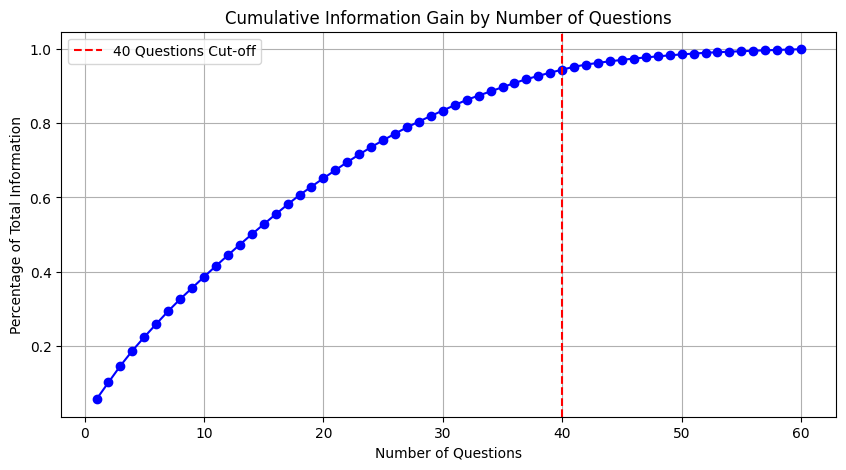

In [20]:
cumulative_mi = top_questions["Average_Score"].cumsum() / top_questions["Average_Score"].sum()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_mi)+1), cumulative_mi, marker="o", color="b")
plt.axvline(x=40, color="r", linestyle="--", label="40 Questions Cut-off")
plt.title("Cumulative Information Gain by Number of Questions")
plt.xlabel("Number of Questions")
plt.ylabel("Percentage of Total Information")
plt.legend()
plt.grid()
plt.show()

In [21]:
selected_columns = top_questions.head(40).index.tolist()

X_selected = df[selected_columns + ["Personality"]]

print(f"Number of columns {df.shape[1]}")
print(f"Number of selected columns: {X_selected.shape[1]}")
print("\nFirst 5 most informative questions in the top 40:")
print("\n".join(selected_columns[:5]))

Number of columns 61
Number of selected columns: 41

First 5 most informative questions in the top 40:
You are not too interested in discussing various interpretations and analyses of creative works.
You are definitely not an artistic type of person.
Your mood can change very quickly.
You usually prefer just doing what you feel like at any given moment instead of planning a particular daily routine.
You tend to avoid drawing attention to yourself.
